# Function 4 - Week 2: exploration

Review this week's observations and latest returned output. Examine input coverage and compare candidate batches for further exploration.

In [2]:
# Imports & shared helpers
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import sys
from IPython.display import display

# Find Shared from any function/week folder inside notebooks.
shared_dir = next(
    (folder / "Shared"
     for folder in (Path.cwd(), *Path.cwd().parents)
     if (folder / "Shared" / "plot_helpers.py").is_file()),
    None,
)
if shared_dir is None:
    raise FileNotFoundError(
        "Cannot find Shared/plot_helpers.py above the working directory. "
        "Run this notebook from within the notebooks folder."
    )
if str(shared_dir) not in sys.path:
    sys.path.insert(0, str(shared_dir))

from plot_helpers import (
    plot_pairwise_ranked_locations,
    plot_pairwise_sampling_gaps,
    plot_pairwise_coverage_comparisons,
    plot_coverage_tradeoff,
    plot_output_distribution,
)
from coverage_helpers import summarise_coverage_results, select_coverage_batch
from coverage_cache import compare_coverage_batches, refine_coverage_batch
from query_budget import remaining_queries
from output_helpers import summarise_output_observations


In [3]:
# Data and output paths for this week's notebook.
# Start the kernel with this notebook's folder as its working directory.
week_dir = Path.cwd().resolve()
full_data_path = week_dir / "observations.csv"

if not (week_dir / "exploration.ipynb").is_file() or not full_data_path.is_file():
    raise FileNotFoundError(
        "Run this notebook with its own folder as the working directory; "
        "exploration.ipynb and observations.csv must be together."
    )

figures = week_dir / "figures"
figures.mkdir(parents=True, exist_ok=True)

# Local generated results; excluded from Git.
coverage_cache = week_dir / ".coverage-cache"


In [4]:
# Basic data load
print(f"Loading data from: {full_data_path}")
data = pd.read_csv(full_data_path)

Loading data from: C:\_Source\Imperial-ML-AI-Live\Capstone\imperial-capstone\stage-2-bbo\notebooks\Function_4\Week_02\observations.csv


In [5]:
# Column inspection
columns = data.columns
print("Columns: ", columns)

Columns:  Index(['observation_id', 'source_round', 'x1', 'x2', 'x3', 'x4', 'y'], dtype='str')


In [6]:
# Where we pray for good data, aka checking for nulls
print (data.isna().sum())

observation_id    0
source_round      0
x1                0
x2                0
x3                0
x4                0
y                 0
dtype: int64


In [7]:
# Prepare observation labels for the exploration plots
plot_data = data.copy()
plot_data["rank"] = (
    plot_data["y"]
    .rank(ascending=False, method="min")
    .astype(int)
)

In [8]:
# Splitting our data into inputs X and outputs y
output_column = "y"
# The course names inputs x1, x2, ...; preserve their CSV column order.
input_columns = [
    name for name in data.columns
    if name.startswith("x") and name[1:].isdigit()
]

#print("Input columns: ", input_columns)
#print("Output column: ", output_column)

X = data[input_columns]
y = data[output_column]

#print("The inputs are given by :")
#print(X.head())
#print("The outputs are given by :")
#print(y[:5])


In [9]:
# So now we have:

# data	       = Observations as loaded from the CSV
# X, y	       = Inputs and outputs selected from those observations
# plot_data	   = A separate copy enriched for the exploration plots

In [10]:
# Review the latest recorded submission against earlier observed outputs.
output_review = summarise_output_observations(
    data,
    input_columns=input_columns,
    output_column=output_column,
)
print(output_review["report"])


Latest recorded submission: round 1 (1 new output).
Compared with 30 earlier observations; rank 1 = highest of all 31 outputs.
Earlier output range: [-32.625660216, -4.02554228191].

round-01: y = -2.73815743419 (negative); rank 1/31.
Inputs: x1 = 0.377878, x2 = 0.477308, x3 = 0.239218, x4 = 0.43529
New highest observed output. Smallest non-zero magnitude so far (1.47 times smaller than the earlier smallest).


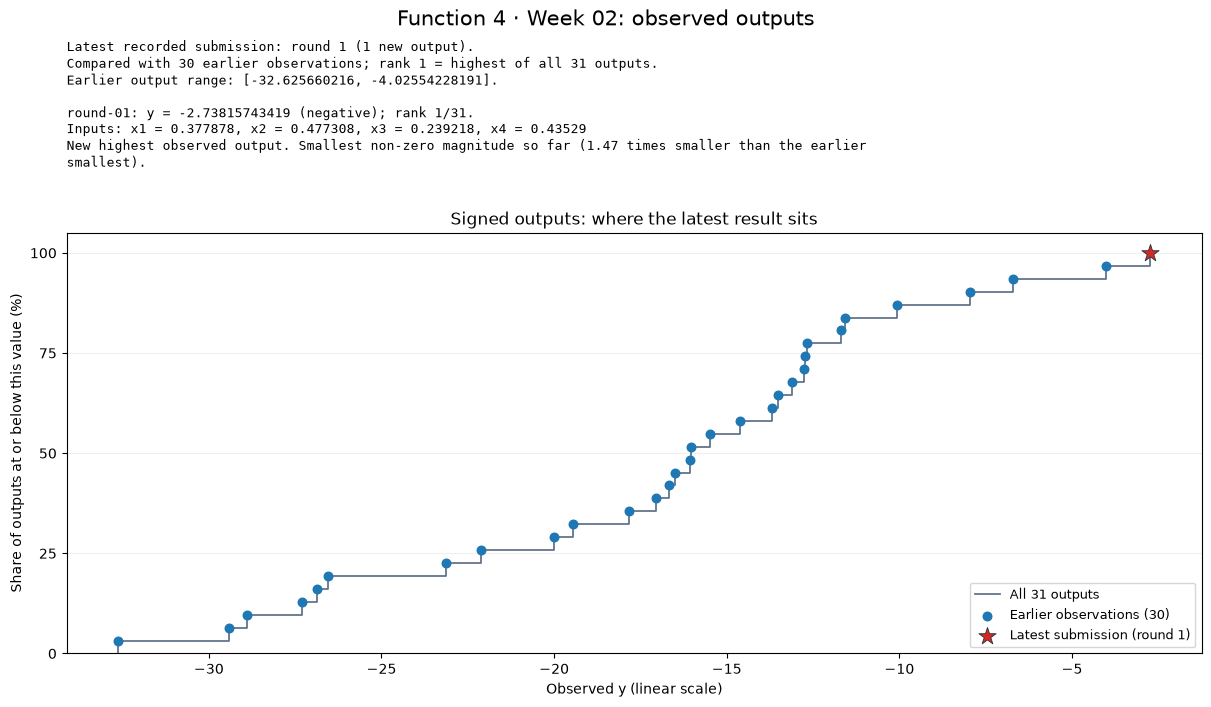

In [11]:
# Show every output, highlight the latest result and save a chart for the weekly write-up.
plot_output_distribution(
    output_review,
    title=f"{week_dir.parent.name.replace('_', ' ')} · {week_dir.name.replace('_', ' ')}: observed outputs",
    save_to=figures / "output-distribution.png",
)


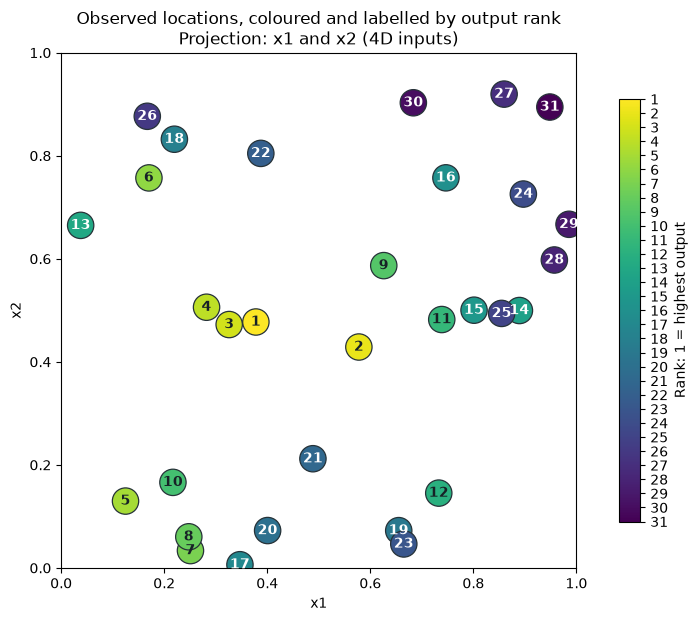

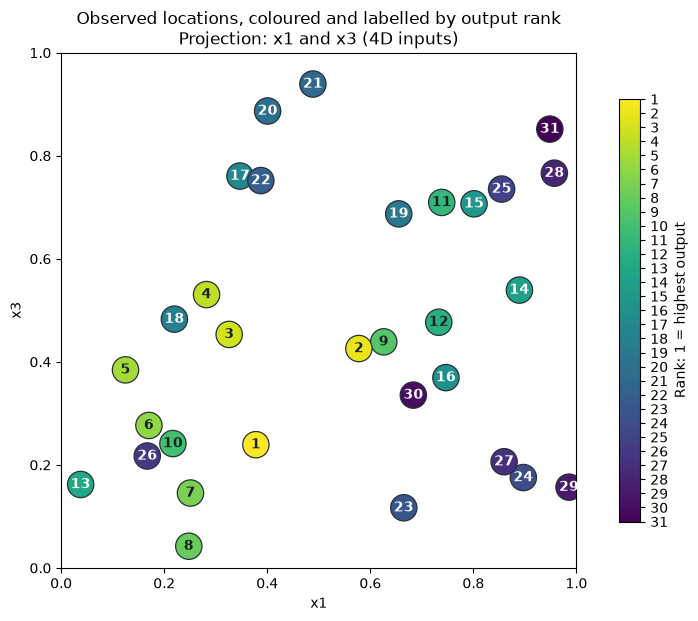

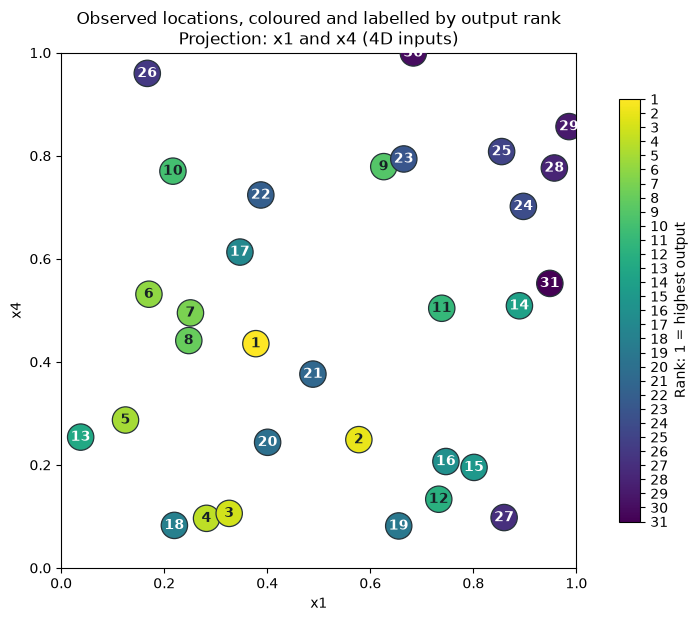

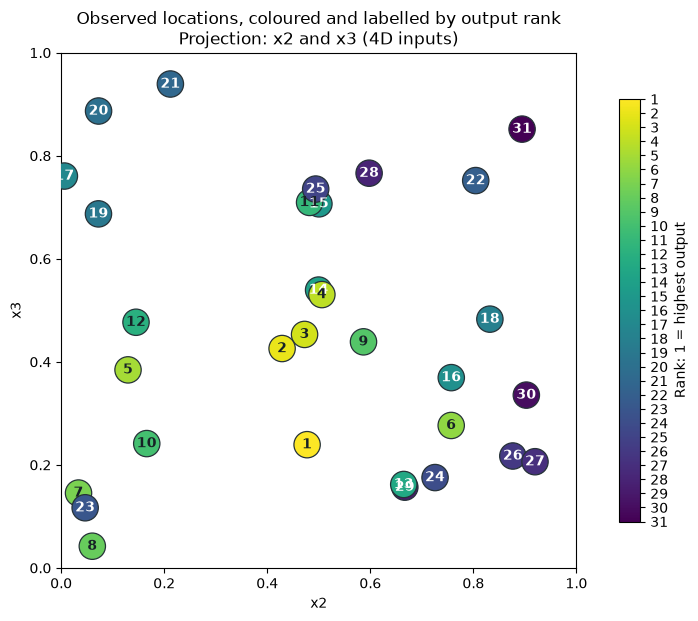

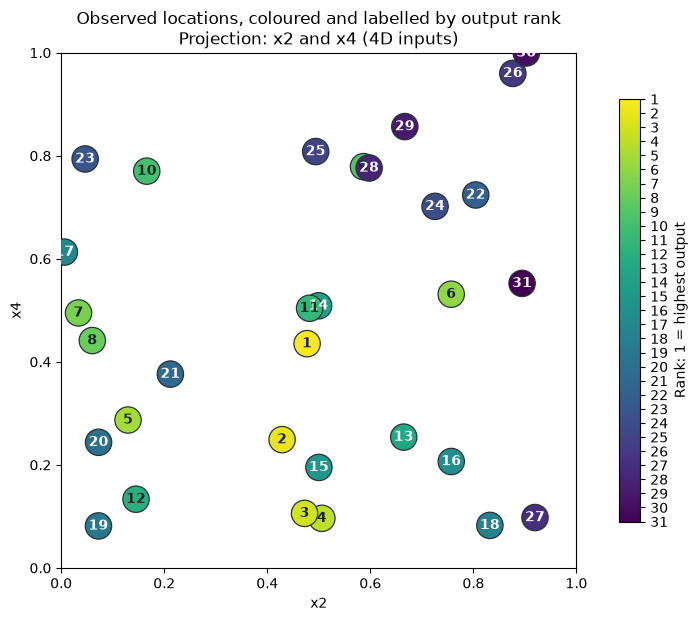

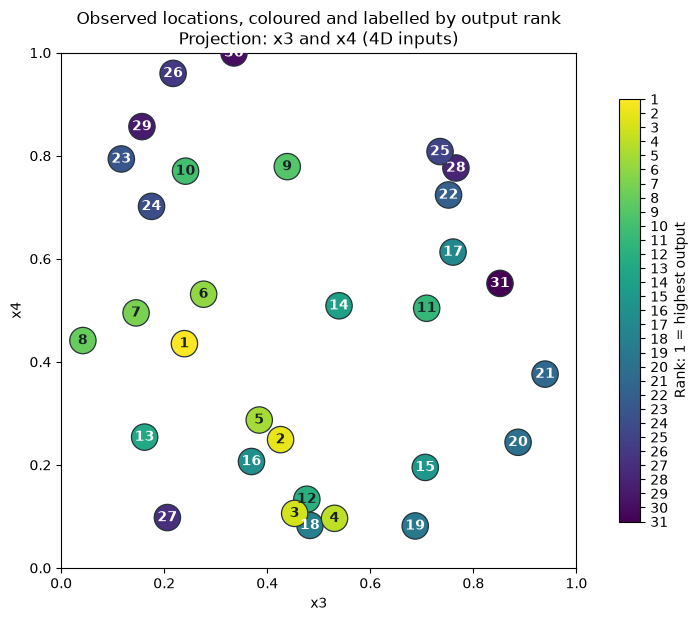

In [12]:
# Analysis of input space coverage and output ranking.

# Show every input pair, labelled by the observations' output ranks.
ranked_location_figures = plot_pairwise_ranked_locations(
    plot_data,
    input_columns=input_columns,
    save_to=figures / "ranked-locations.png",
)
for ranked_figure in ranked_location_figures.values():
    display(ranked_figure)


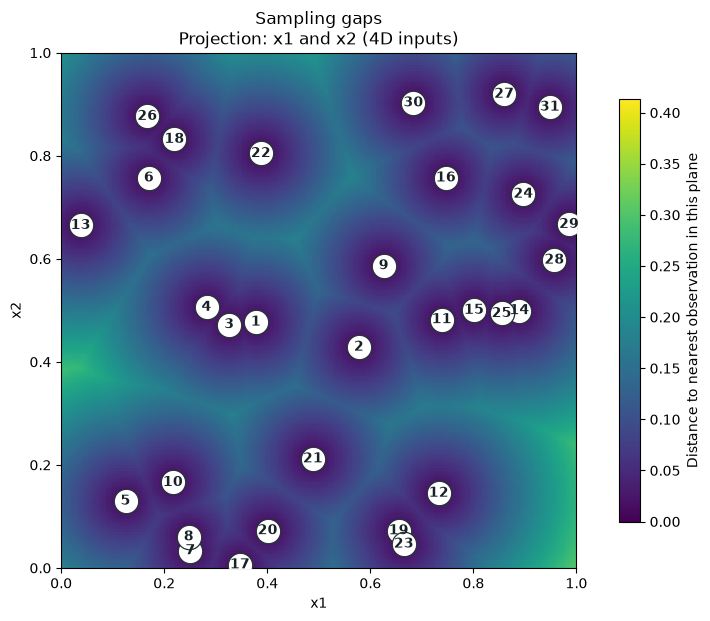

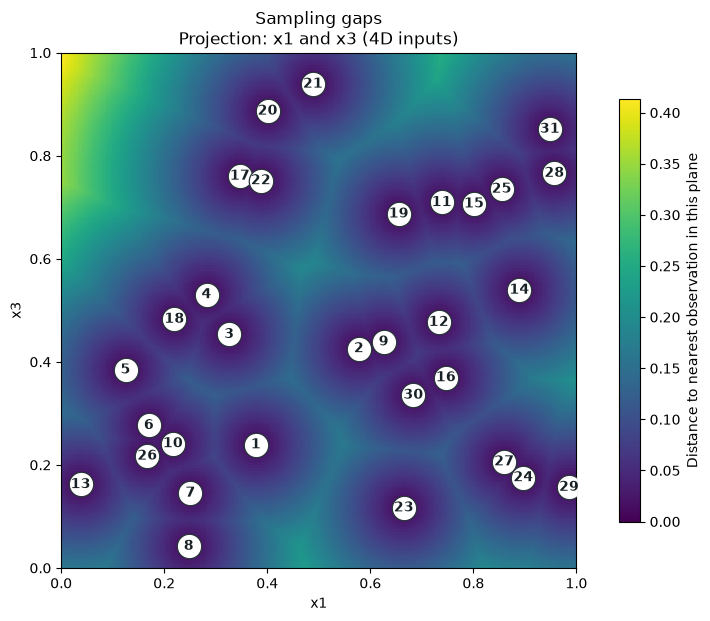

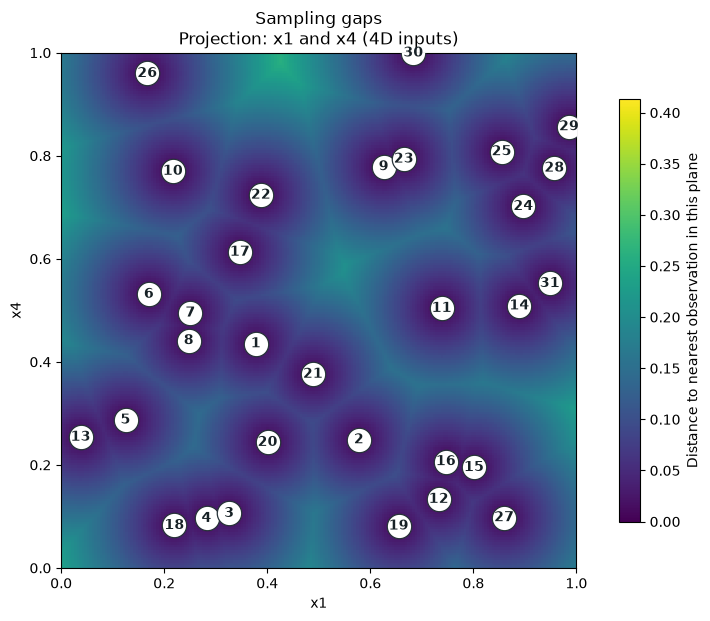

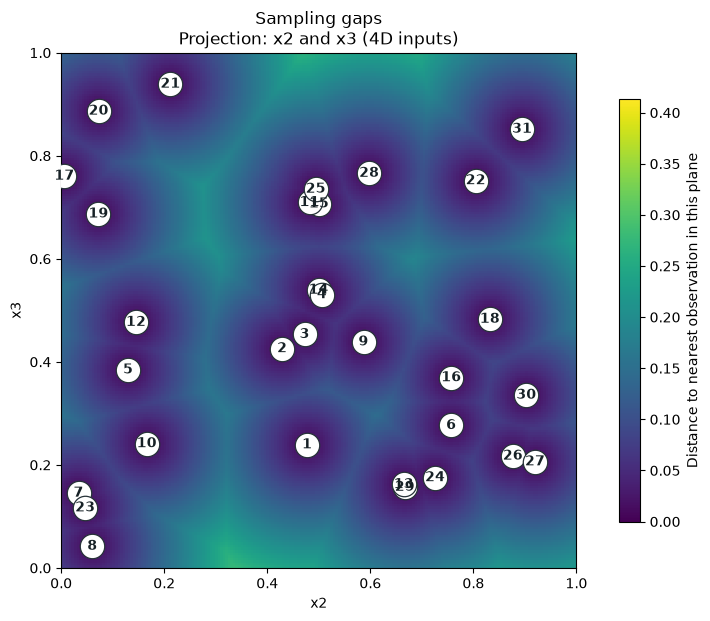

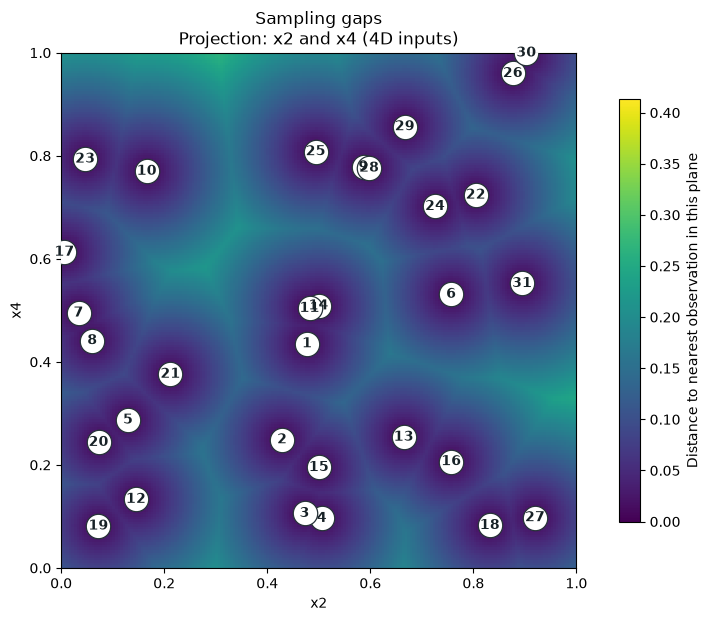

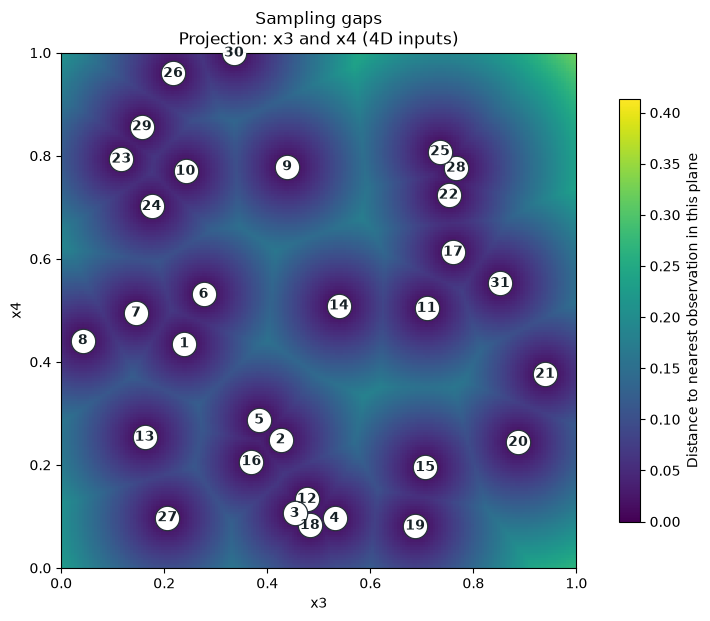

In [13]:
# Visualise sampling gaps in every input pair, using a shared colour scale.
# These are 2D projections; the coverage search measures distances in all dimensions.
sampling_gap_figures = plot_pairwise_sampling_gaps(
    plot_data,
    input_columns=input_columns,
    save_to=figures / "sampling-gaps.png",
)
for gap_figure in sampling_gap_figures.values():
    display(gap_figure)


In [14]:
# Compare different numbers of additional exploratory queries.
# Include this week's query; the budget falls automatically in later week folders.
max_exploratory_queries = remaining_queries(week_dir)
print(f"Queries remaining for this function: {max_exploratory_queries}")

coverage_comparison = compare_coverage_batches(
    existing=X,
    cache_dir=coverage_cache,
    max_queries=max_exploratory_queries,
)


Queries remaining for this function: 12
q=0: loaded from cache
q=1: loaded from cache
q=2: loaded from cache
q=3: loaded from cache
q=4: loaded from cache
q=5: loaded from cache
q=6: loaded from cache
q=7: loaded from cache
q=8: loaded from cache
q=9: loaded from cache
q=10: loaded from cache
q=11: loaded from cache
q=12: loaded from cache


In [15]:
# Build the coverage table and its relative and marginal improvements.
coverage_results = summarise_coverage_results(coverage_comparison["results"])


In [16]:
# Select the elbow automatically; the helper reports its fallback if the bend is weak.
batch_selection = select_coverage_batch(
    coverage_results["q"],
    coverage_results["max_distance"],
)
selected_q = batch_selection["q"]
print(batch_selection["message"])


Selected 2 exploratory queries at the elbow (normalised bend: 0.091).


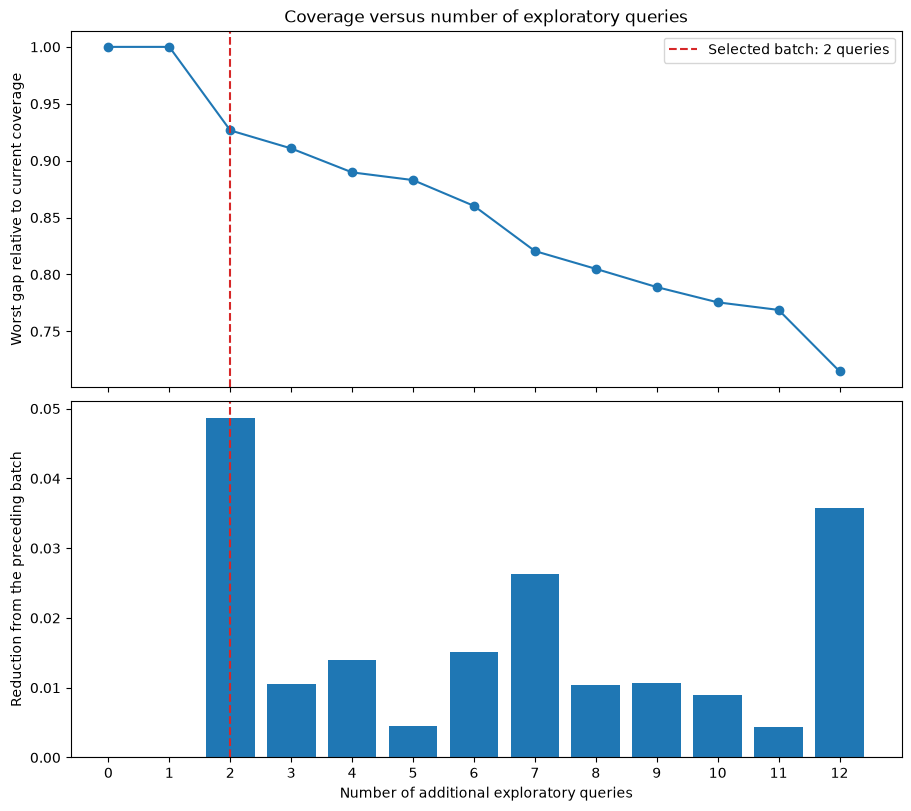

In [17]:
# Keep the selected-q marker aligned across both coverage charts.
plot_coverage_tradeoff(
    coverage_results,
    selected_q,
    save_to=figures / "coverage-batch-selection.png",
)


In [18]:
# Refine the selected batch, retaining the comparison result too.
# Keep the refinement seeds explicit for each week's exploration.
best_batch = refine_coverage_batch(
    existing=X,
    selected_q=selected_q,
    comparison=coverage_comparison,
    cache_dir=coverage_cache,
    seeds=range(5),
)


q=2, seed=0: loaded from cache
q=2, seed=1: loaded from cache
q=2, seed=2: loaded from cache
q=2, seed=3: loaded from cache
q=2, seed=4: loaded from cache
Best batch: 2 queries, seed 42, maximum assessment distance 0.6152.


In [19]:
# Preserve every input dimension and its original column name.
coverage_queries = pd.DataFrame(
    best_batch["proposed"],
    columns=X.columns,
)

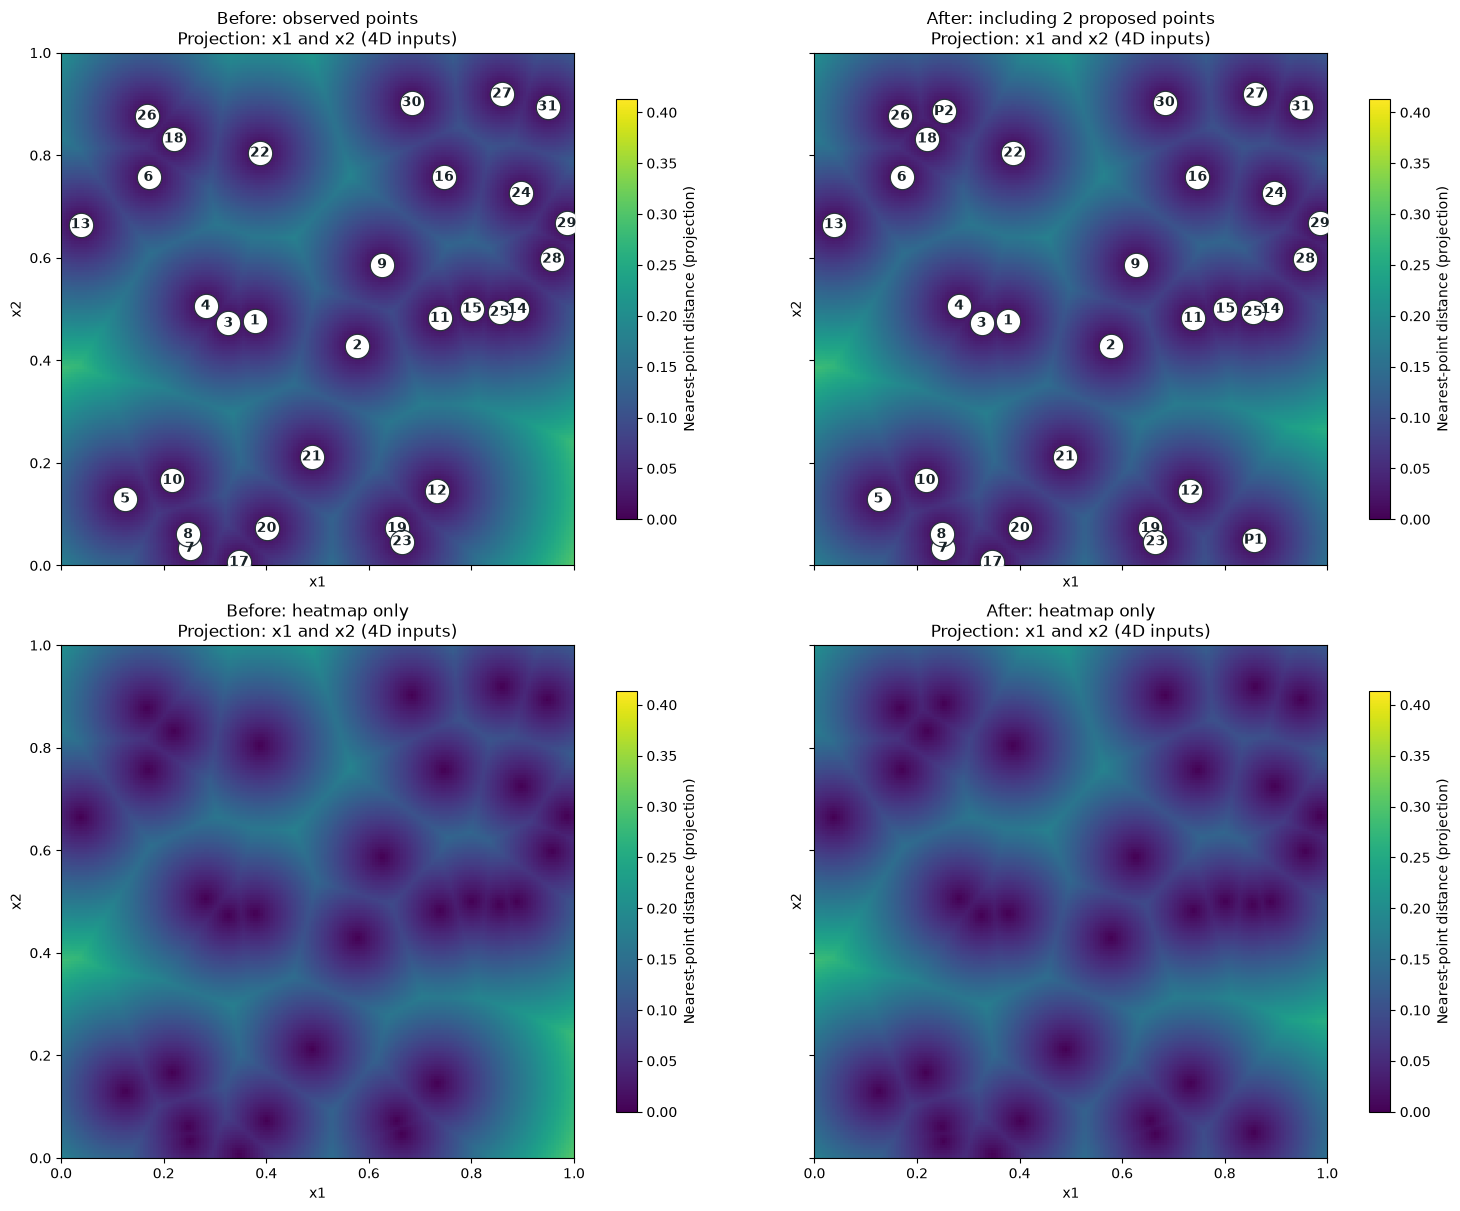

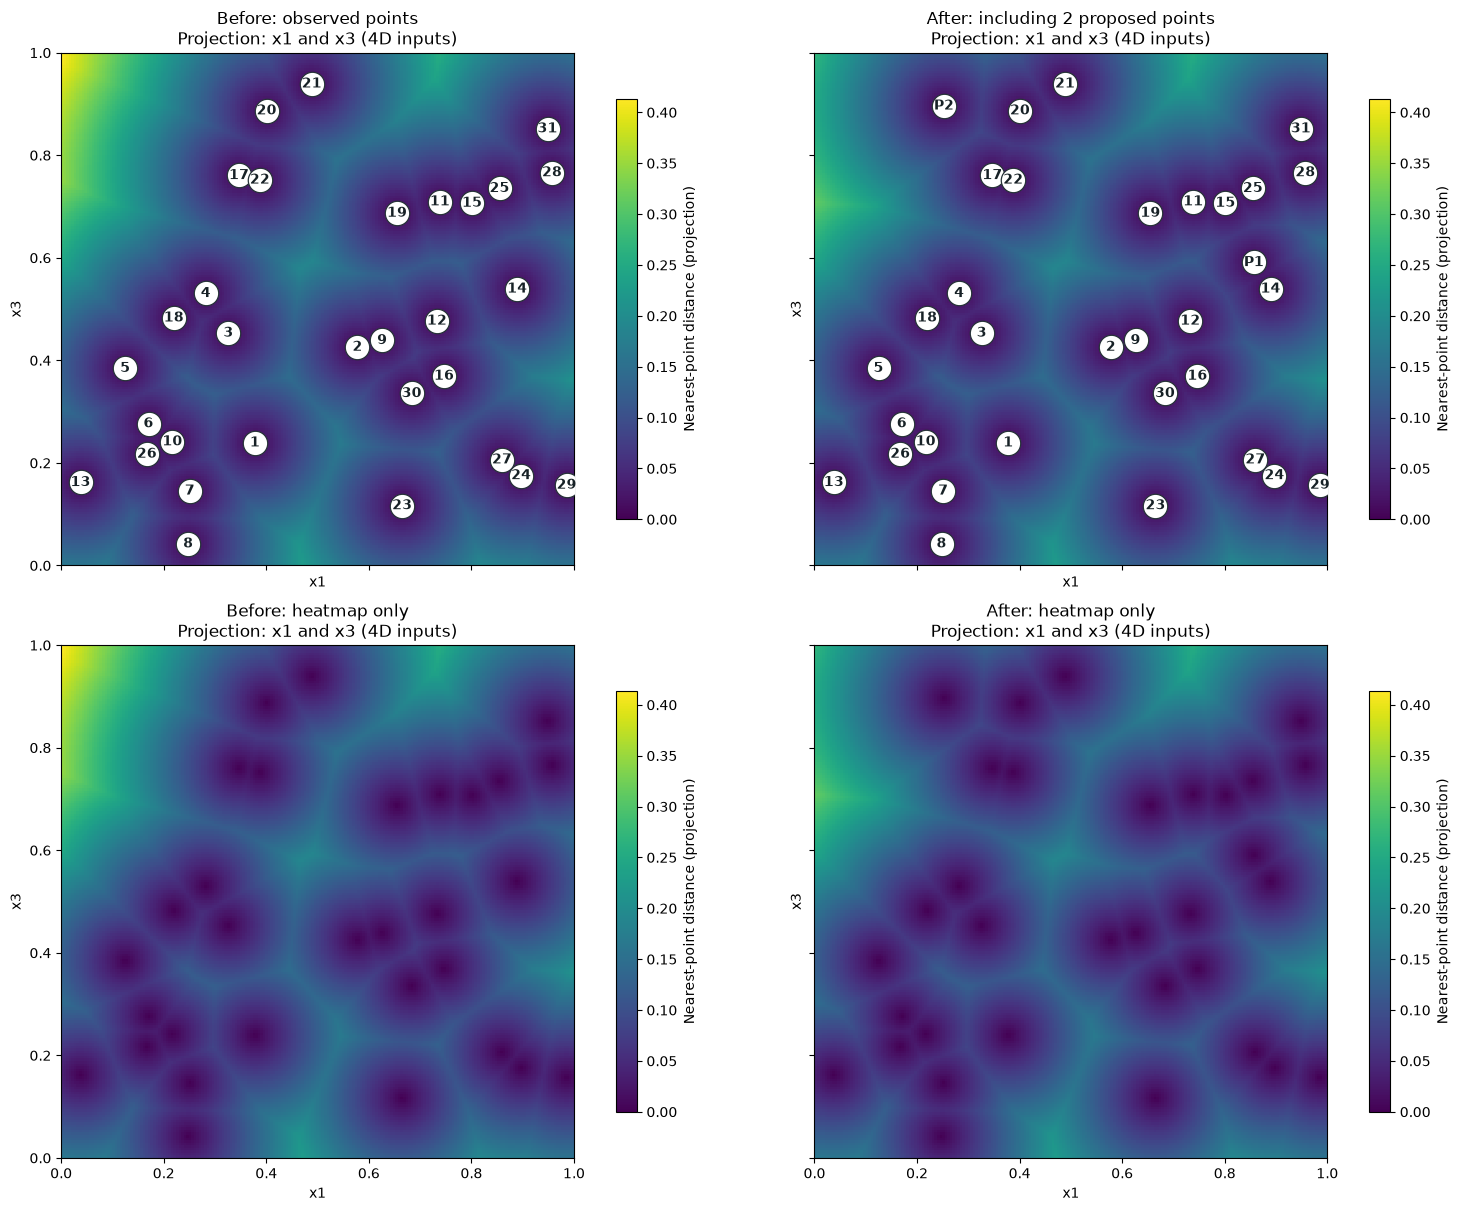

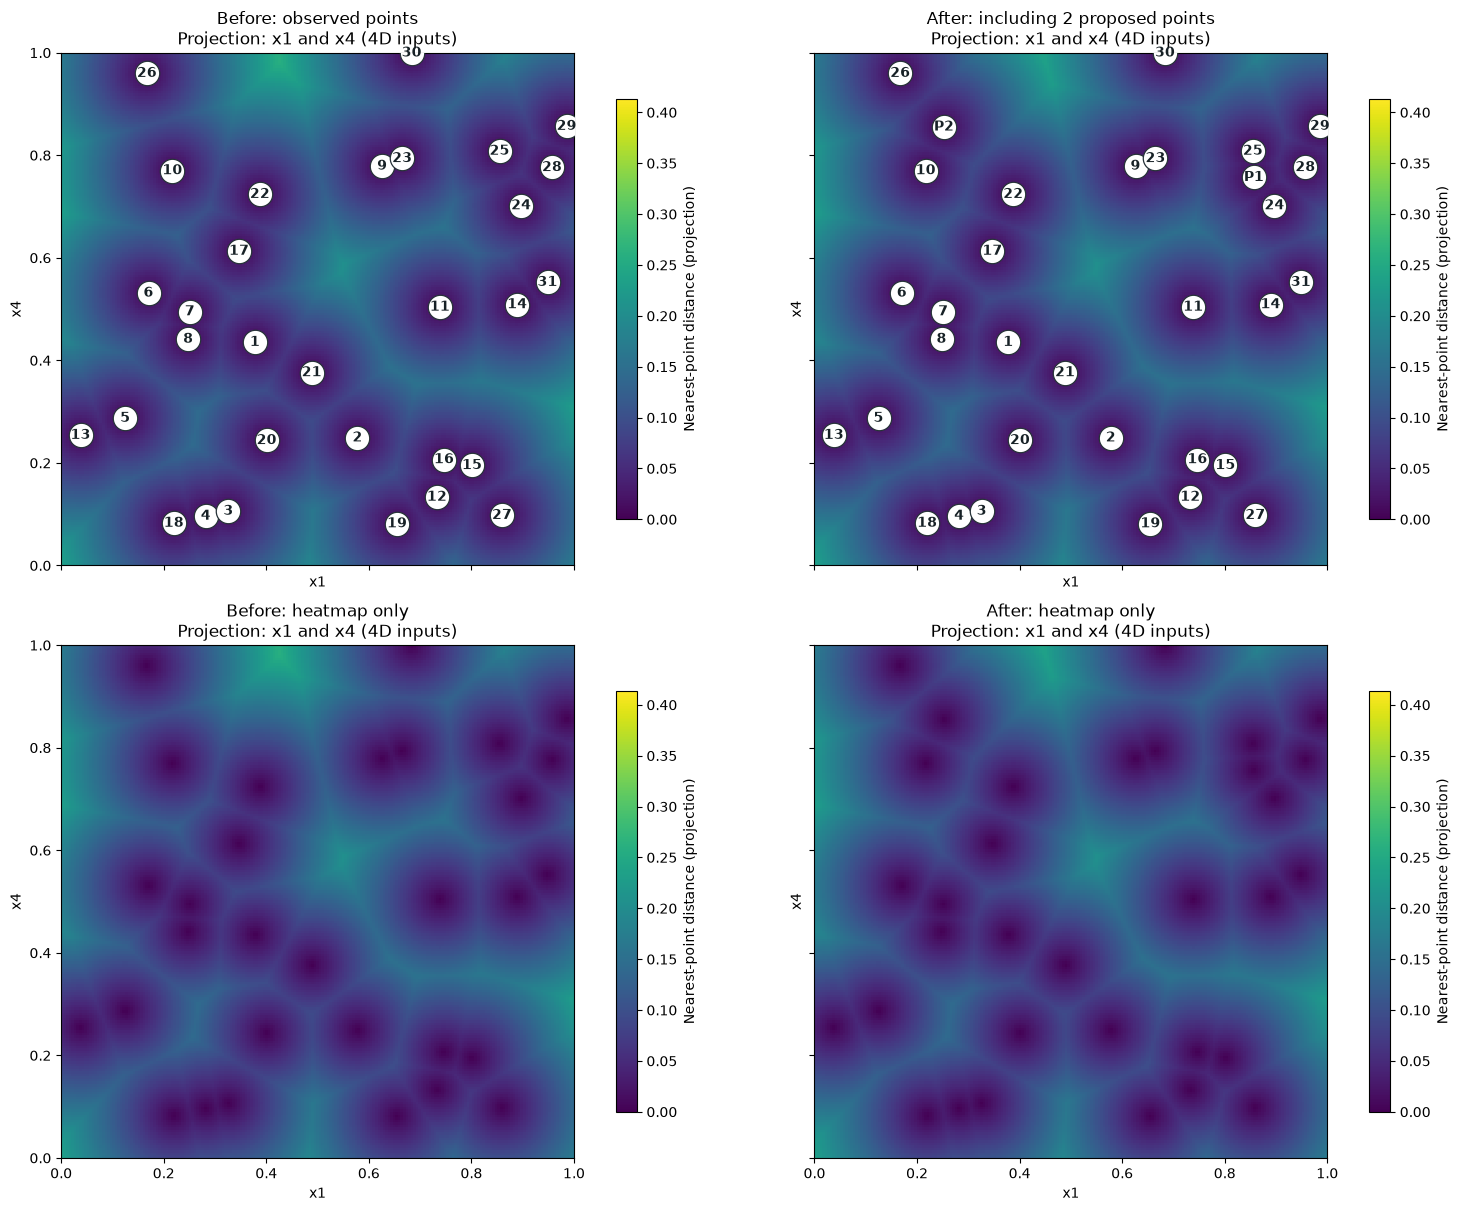

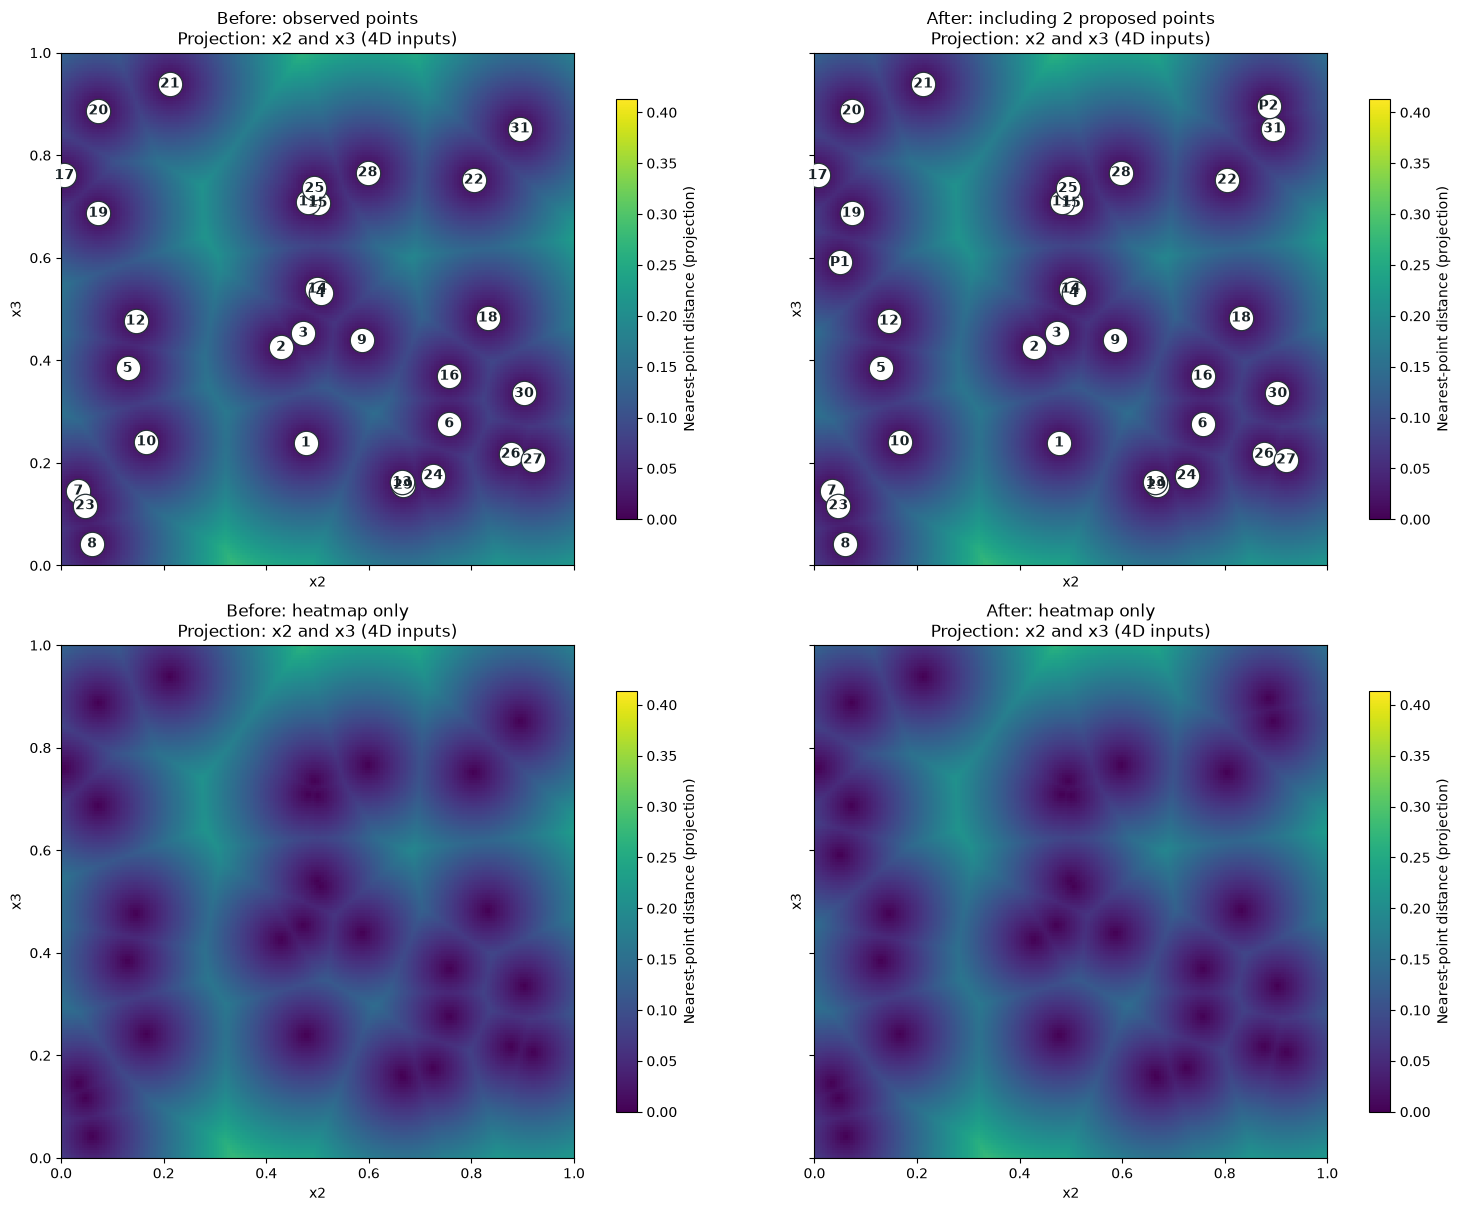

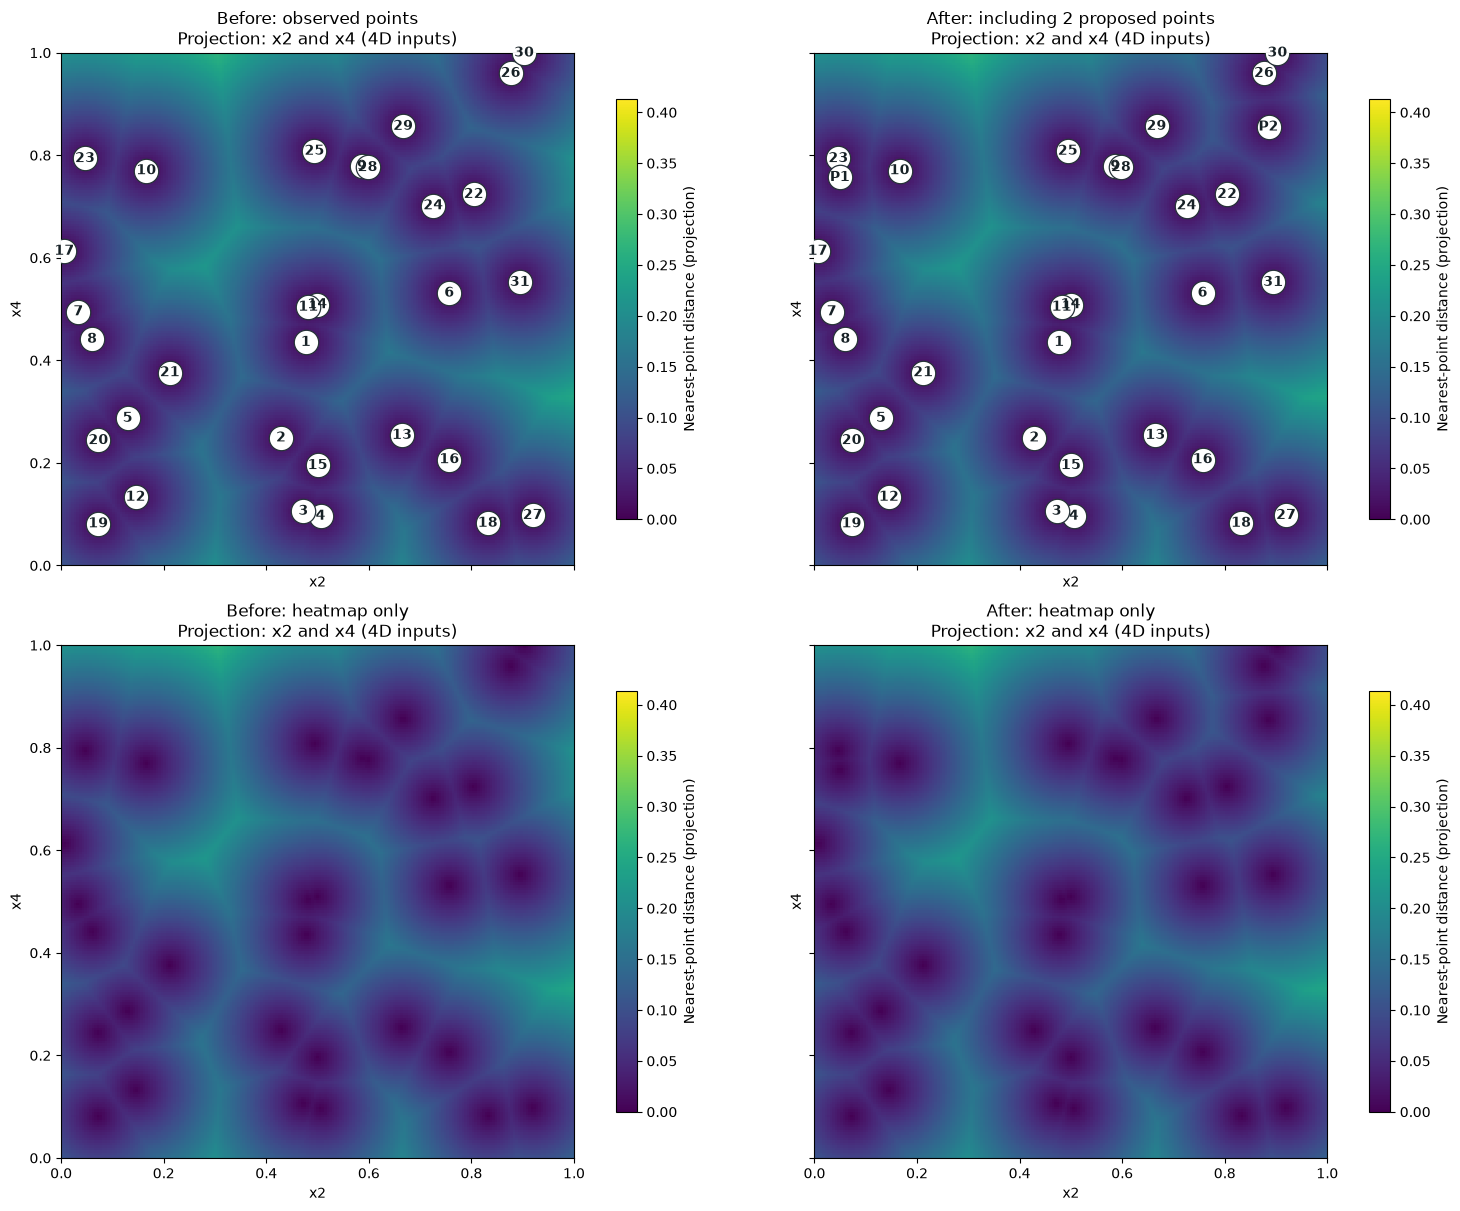

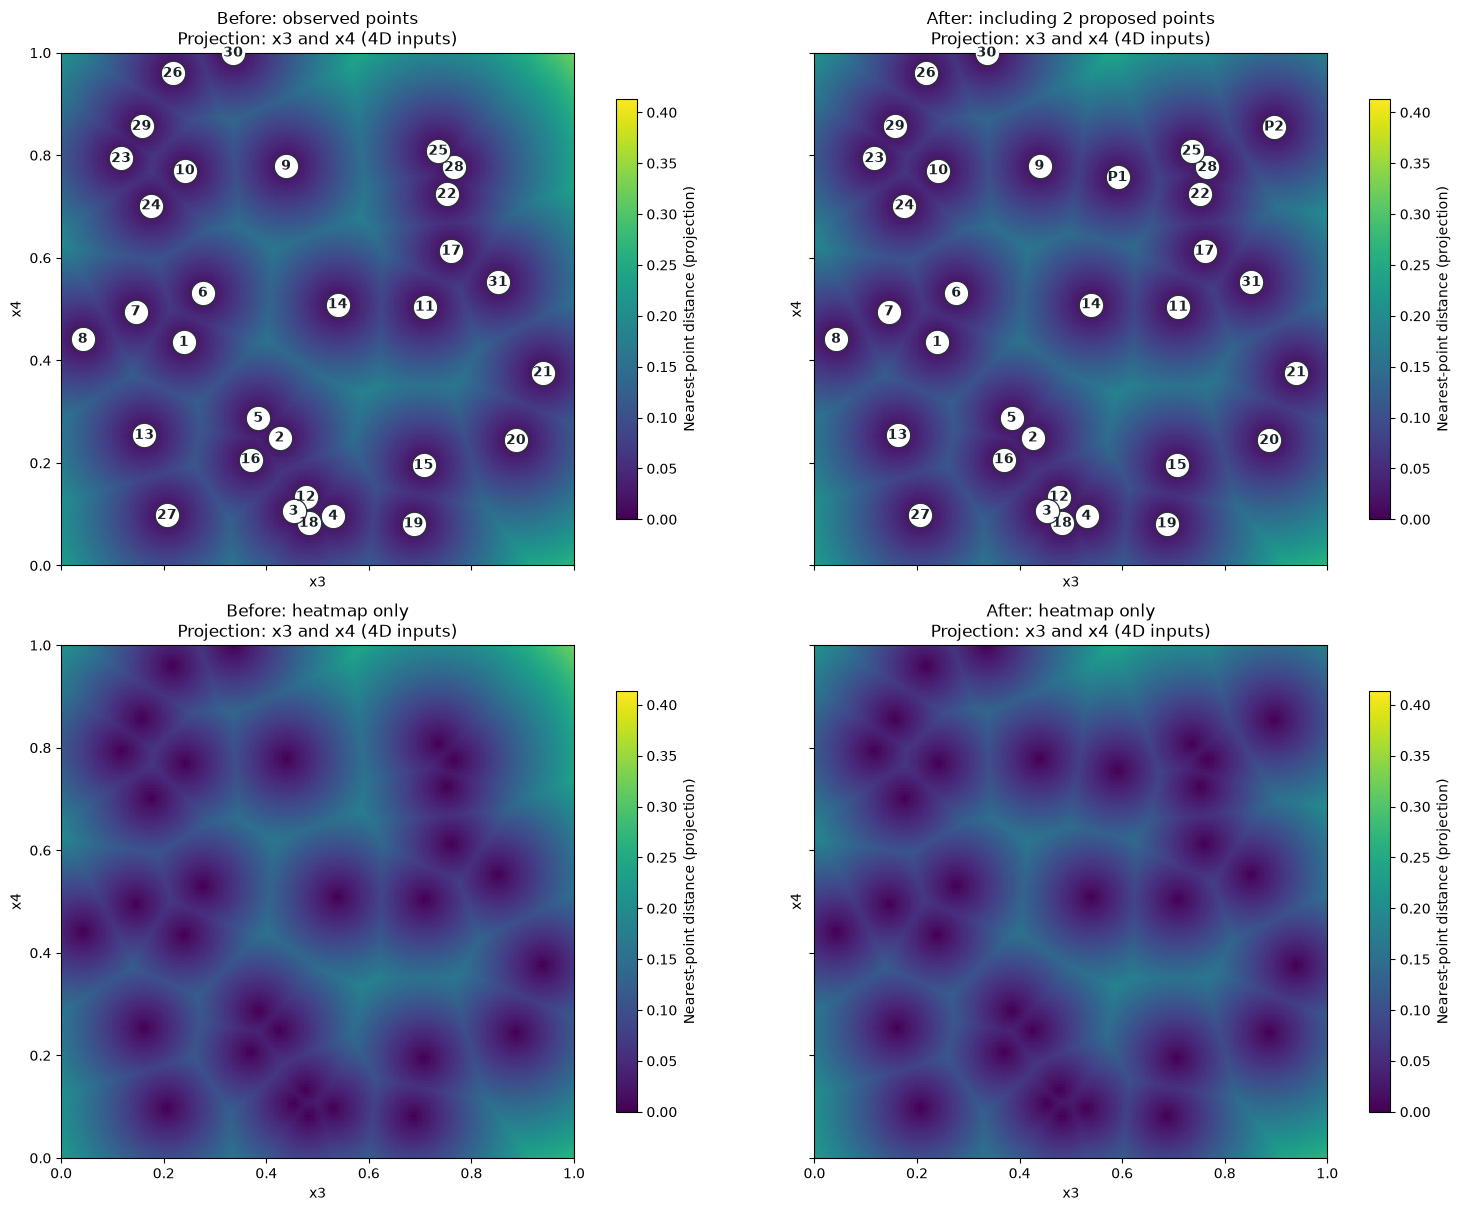

In [20]:
# Compare every distinct input pair, with labels and then with heatmaps alone.
# These are 2D projections of a coverage search that uses all input dimensions.
# None shares the largest before gap across all pairs; fix vmax to compare weeks.
coverage_figures = plot_pairwise_coverage_comparisons(
    plot_data,
    coverage_queries,
    vmax=None,
    save_to=figures / "sampling-gaps-comparison.png",
)
for comparison_figure in coverage_figures.values():
    display(comparison_figure)


In [21]:
# Current candidates for improving geometric coverage.
#
# Function 4's previous model-guided query produced a new best observed output,
# and earlier validation supported using fitted models.
#
# We will therefore choose the next submission using model predictions
# and the value of further learning, instead of committing to this batch.
# Further exploration remains available; reassess after each returned result.
coverage_queries

,x1,x2,x3,x4
0,0.856912,0.049581,0.590909,0.756873
1,0.252504,0.885335,0.896208,0.855253
